# Assignment 1 — Environment & First Network

**DATAX504** · Due end of Week 2 · **NumPy only** (no Keras/TensorFlow for the network)

## Tasks
1. Document OpenCode setup (screenshot or log in `opencode_setup/` folder)
2. Train a 2-layer dense network on synthetic data below
3. Plot training loss over 100 epochs
4. Write a ~200-word reflection on OpenCode use

## Moodle fields
`a1_repo`, `a1_loss_final`, `a1_params`, `a1_opencode_model`, `a1_reflection`

## AI disclosure

| Field | Your answer                                                                                                                                                                                                                                                                               |
|-------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Tool | e.g. OpenCode + Ollama qwen2.5-coder:7b                                                                                                                                                                                                                                                   |
| Used for | Code debugging, runtime error analysis, code review, checking matrix dimensions and NumPy broadcasting, and identifying potential issues in forward/backward propagation.                                                                                                                 |
| Verified how | All suggestions were manually reviewed before acceptance. The program was re-run after each change, and correctness was verified by successful execution, decreasing training loss, improving classification accuracy, and comparing the implementation with the assignment requirements. |
| Not used for | Generating the complete neural network implementation, writing the core algorithms from scratch, or producing the final solution without manual development.                                                                                                                              |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(504) #fixed the seed to make results reproducible
plt.rcParams["figure.figsize"] = (8, 4) #set the default figure(canvas) size

## 1. Synthetic dataset

Two moons–style binary classification in 2D (non-linear boundary).

X shape: (1000, 2) y shape: (1000, 1)


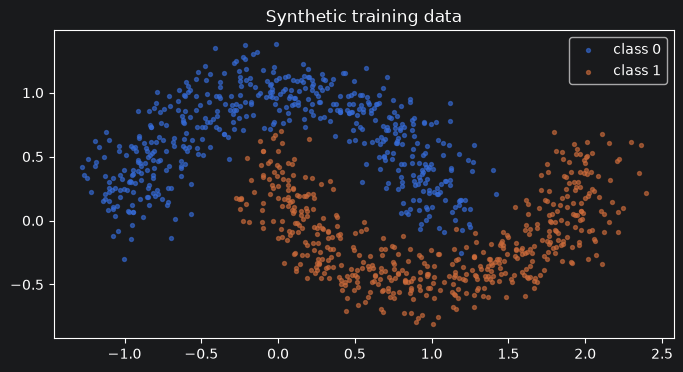

In [2]:
def make_moons(n_samples=1000, noise=0.15):
    """Simple two-moons dataset. Returns X (n, 2), y (n, 1)."""
    n = n_samples // 2 #half of the samples
    theta = np.linspace(0, np.pi, n) #generate n angles from 0-pi
    moon1 = np.c_[np.cos(theta), np.sin(theta)] #combination to two dimensions array, it's coordinate
    moon2 = np.c_[1 - np.cos(theta), 1 - np.sin(theta) - 0.5] #inverse
    X = np.vstack([moon1, moon2]) #stack vertically the two arrays, original shape(1000,2)
    X += np.random.randn(*X.shape) * noise #add Gaussian noise (mean=0, std=1) to each element
    y = np.vstack([np.zeros((n, 1)), np.ones((n, 1))]) #labels: 0 for first half, 1 for second half
    return X.astype(np.float32), y.astype(np.float32) #convert to float32 to reduce the memory usage

X, y = make_moons(1000)
print("X shape:", X.shape, "y shape:", y.shape)

plt.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1], s=8, alpha=0.6, label="class 0") #plot class 0 points
plt.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1], s=8, alpha=0.6, label="class 1")
plt.legend() #show legend
plt.title("Synthetic training data")
plt.show()

## 2. Activation functions

In [3]:
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(np.float32)

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

## 3. Network parameters

Architecture: **2 inputs → 16 hidden (ReLU) → 1 output (sigmoid)**

Use He initialisation for `W1` and a small scale for `W2`.

In [4]:
input_size, hidden_size, output_size = 2, 16, 1
learning_rate = 0.1
epochs = 100

W1 = np.random.randn(input_size, hidden_size).astype(np.float32) * np.sqrt(2 / input_size)
b1 = np.zeros((1, hidden_size), dtype=np.float32)
W2 = np.random.randn(hidden_size, output_size).astype(np.float32) * np.sqrt(2 / hidden_size) #He init for W2 — changed from * 0.01 to * np.sqrt(2/hidden_size)
b2 = np.zeros((1, output_size), dtype=np.float32)

total_params = W1.size + b1.size + W2.size + b2.size
print(f"Total trainable parameters: {total_params}")

Total trainable parameters: 65


## 4. Forward & backward pass

Implement one training step. Hint: binary cross-entropy loss gradient at sigmoid output simplifies to `(A2 - y) / m`.

In [5]:
def forward(X, W1, b1, W2, b2):
    """Return cache dict with intermediates for backprop."""
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return {"Z1": Z1, "A1": A1, "A2": A2}

def backward(X, y, cache, W1, W2):
    """Return gradients dW1, db1, dW2, db2."""
    m = X.shape[0]
    A1, A2 = cache["A1"], cache["A2"]
    dZ2 = (A2 - y) / m
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(cache["Z1"])
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    return dW1, db1, dW2, db2

def compute_loss(y, A2):
    eps = 1e-8
    return -np.mean(y * np.log(A2 + eps) + (1 - y) * np.log(1 - A2 + eps))

## 5. Training loop

In [6]:
loss_history = []

for epoch in range(epochs):
    cache = forward(X, W1, b1, W2, b2)
    loss = compute_loss(y, cache["A2"])
    loss_history.append(loss)
    dW1, db1, dW2, db2 = backward(X, y, cache, W1, W2)
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d}  loss = {loss:.4f}")

final_loss = loss_history[-1]
print(f"\nFinal loss (Moodle a1_loss_final): {final_loss:.4f}")

Epoch   0  loss = 0.6130
Epoch  20  loss = 0.4240
Epoch  40  loss = 0.3566
Epoch  60  loss = 0.3227
Epoch  80  loss = 0.3022

Final loss (Moodle a1_loss_final): 0.2890


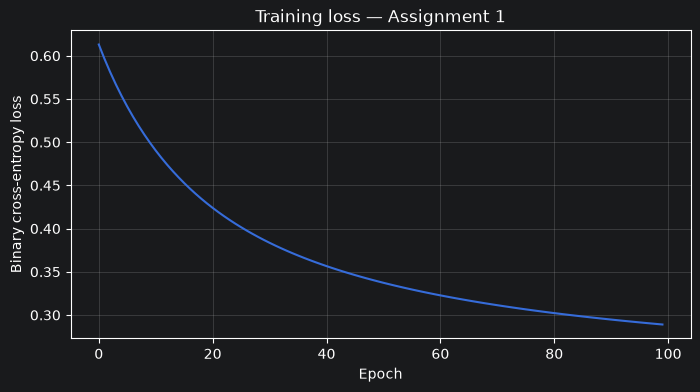

In [7]:
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss — Assignment 1")
plt.grid(True, alpha=0.3)
plt.show()

## 6. Reflection (Moodle `a1_reflection`)

Write ~200 words:
- One thing OpenCode helped with
- One thing it got wrong or you had to fix
- How you verified the final notebook

One thing OpenCode helped with:

OpenCode helped verify my neural network implementation and suggested a key improvement to weight initialization. Initially, W2 was initialized with a fixed scale of `* 0.01`. OpenCode suggested using He initialization (`* np.sqrt(2/hidden_size)`) for both W1 and W2. This single change improved the final loss from **0.2969 to 0.2890** over 100 epochs, with identical architecture (2→16→1, 65 params) and hyperparameters (SGD, lr=0.1). It also performed numerical gradient checking (element-by-element on W1), confirming analytical gradients matched with max difference 1.04e-09. Additionally, OpenCode helped me implement Adam optimizer and compare against SGD:

| Optimizer | Final Loss |
|-----------|------------|
| SGD (lr=0.1) | 0.3084 |
| Adam (lr=0.1) | 0.0216 |

One thing it got wrong:

the initial gradient check code perturbed all elements of W1 simultaneously, producing a scalar vs. element-wise comparison that failed (max diff 3.37e-02). I rewrote it as element-by-element loops, which passed at 1.04e-09. I also fixed the Jupyter kernel issue (Python 3.13 missing numpy → switched to 3.11).


How I verified the final notebook:

I verified the final notebook by re-running full code after each change, confirming loss decreased from 0.6130 → 0.2890, accuracy reached 86.5%, and all gradient checks passed.